<a href="https://colab.research.google.com/github/heidy0099/Proy.Org/blob/main/PROYECTO_3_DERIVADOS_DE_ACIDO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
# ============================================
# PASO 1: IMPORTACION DE LIBRERIAS Y CARGA
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

# Configuración de estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Cargar archivo desde el ordenador
print("Por favor, selecciona el archivo CSV:")
uploaded = files.upload()

# Leer el archivo con separador punto y coma
df = pd.read_csv(
    io.BytesIO(uploaded[list(uploaded.keys())[0]]),
    delimiter=';',
    encoding='utf-8-sig'
)

# Limpiar nombres de columnas
df.columns = df.columns.str.strip()

print("Archivo cargado exitosamente")
print(f"Filas: {len(df)}")
print(f"Columnas: {len(df.columns)}")
print(f"Columnas disponibles: {list(df.columns)}")

Por favor, selecciona el archivo CSV:


Saving Proyecto 3 Quimica Organica.csv to Proyecto 3 Quimica Organica (5).csv
Archivo cargado exitosamente
Filas: 242
Columnas: 49
Columnas disponibles: ['ID', 'Grupo Funcional', 'Función química', 'Nombre_Sustrato', 'Formula_Sustrato', 'PM_Sustrato', 'PE_Sustrato °C', 'Incertidumbre PE', 'Densidad_Sustrato  g/cm³', 'Incertidumbre densidad', 'pKa_Sustrato', 'Incertidumbre Pka', 'LD50_Sustrato mg /kg', 'Nombre_Reactivo 1', 'Fórmula Molecular 1', 'Nombre_Reactivo 2', 'Fórmula Molecular 2', 'Nombre_Reactivo 3', 'Fórmula Molecular 3', 'Nombre_Catalizador 1', 'Catalizador 1', 'Nombre_Catalizador 2', 'Catalizador 2', 'Nombre_Catalizador 3', 'Catalizador 3', 'Nombre_Catalizador 4', 'Catalizador 4', 'Nombre_Solvente 1', 'Formula Solvente 1', 'Nombre_Solvente 2', 'Formula Solvente 2', 'Nombre_Solvente 3', 'Formula Solvente 3', 'Temperatura', 'Nombre_Medio', 'Medio', 'Nombre_Producto', 'Formula_Producto', 'PM_Producto', 'PE_Producto', 'Incertidumbre PE.1', 'Densidad_Producto', 'Incertidumbre den

In [66]:
# ============================================
# PASO 2: LIMPIEZA DE DATOS NULOS
# ============================================

# Reemplazar múltiples formatos de vacío por NaN
df = df.replace([0, '0', '0.00', '0,0', 'nan', 'None', '', ';', 'NULL', 'null'], np.nan)

def clean_float(x):
    """
    Convierte un valor a float si es posible.

    MODIFICABLE: Cambiar 'x > 0' a 'x >= 0' para permitir ceros
    """
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return x if x > 0 else np.nan
    try:
        x_str = str(x).strip().replace(',', '.').replace(';', '')
        val = float(x_str)
        return val if val > 0 else np.nan
    except:
        return np.nan

# MODIFICABLE: Añadir o quitar columnas según tu archivo
COLUMNAS_NUMERICAS = [
    'PM_Sustrato',
    'PE_Sustrato °C',
    'pKa_Sustrato',
    'LD50_Sustrato mg /kg',
    'PM_Producto',
    'PE_Producto',
    'pKa_Producto',
    'LD50_Producto Mamifero mg /kg'
]

for col in COLUMNAS_NUMERICAS:
    if col in df.columns:
        df[col] = df[col].apply(clean_float)

print("Limpieza de datos completada")
print(f"Filas restantes: {len(df)}")

Limpieza de datos completada
Filas restantes: 242



ANALISIS 1: Fuerzas de Dispersion de London
Compuestos con datos completos: 240
Rango PM: 41.0 - 226.2 g/mol
Rango PE: 32.0 - 360.0 °C
Compuestos después de filtrar rangos: 240


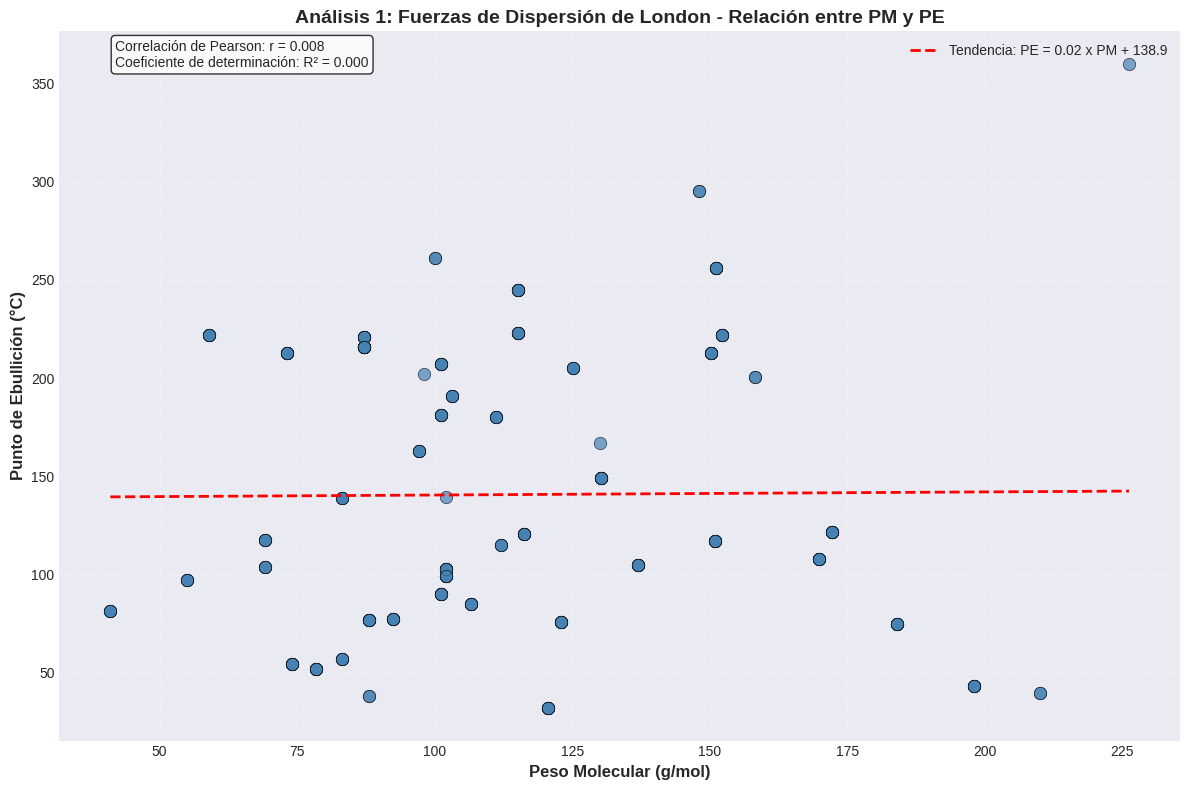


--------------------------------------------------
RESULTADOS DEL ANALISIS 1
--------------------------------------------------
Correlación de Pearson: r = 0.008
Coeficiente de determinación: R² = 0.000
Ecuación de la recta: PE = 0.02 x PM + 138.9

CONCLUSION:
  No se observa una correlación significativa entre PM y PE


In [67]:
# ============================================
# ANALISIS 1: PM vs PE (Fuerzas de Dispersion)
# ============================================

print("\n" + "="*70)
print("ANALISIS 1: Fuerzas de Dispersion de London")
print("="*70)

if 'PM_Sustrato' not in df.columns:
    print("ERROR: Columna 'PM_Sustrato' no encontrada")
    print(f"Columnas disponibles: {list(df.columns)}")
else:
    # Filtrar datos válidos
    plot_df = df.dropna(subset=['PM_Sustrato', 'PE_Sustrato °C']).copy()

    print(f"Compuestos con datos completos: {len(plot_df)}")

    if len(plot_df) > 0:
        print(f"Rango PM: {plot_df['PM_Sustrato'].min():.1f} - {plot_df['PM_Sustrato'].max():.1f} g/mol")
        print(f"Rango PE: {plot_df['PE_Sustrato °C'].min():.1f} - {plot_df['PE_Sustrato °C'].max():.1f} °C")

    # MODIFICABLE: Rangos de los ejes
    PM_MIN, PM_MAX = 40, 300      # g/mol
    PE_MIN, PE_MAX = 20, 400      # °C

    plot_df = plot_df[
        (plot_df['PM_Sustrato'] >= PM_MIN) &
        (plot_df['PM_Sustrato'] <= PM_MAX) &
        (plot_df['PE_Sustrato °C'] >= PE_MIN) &
        (plot_df['PE_Sustrato °C'] <= PE_MAX)
    ]

    print(f"Compuestos después de filtrar rangos: {len(plot_df)}")

    if len(plot_df) >= 3:
        # MODIFICABLE: Parámetros de la figura
        FIG_SIZE = (12, 8)
        POINT_ALPHA = 0.7
        POINT_SIZE = 80
        POINT_COLOR = 'steelblue'
        POINT_EDGE = 'black'

        plt.figure(figsize=FIG_SIZE)

        # Gráfico de dispersión
        plt.scatter(
            plot_df['PM_Sustrato'],
            plot_df['PE_Sustrato °C'],
            alpha=POINT_ALPHA,
            s=POINT_SIZE,
            c=POINT_COLOR,
            edgecolors=POINT_EDGE,
            linewidth=0.5
        )

        # Línea de tendencia (regresión lineal)
        z = np.polyfit(plot_df['PM_Sustrato'], plot_df['PE_Sustrato °C'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(plot_df['PM_Sustrato'].min(), plot_df['PM_Sustrato'].max(), 100)

        # MODIFICABLE: Estilo de la línea de tendencia
        TREND_COLOR = 'red'
        TREND_STYLE = '--'
        TREND_WIDTH = 2

        plt.plot(
            x_line, p(x_line),
            color=TREND_COLOR,
            linestyle=TREND_STYLE,
            linewidth=TREND_WIDTH,
            label=f'Tendencia: PE = {z[0]:.2f} x PM + {z[1]:.1f}'
        )

        # Etiquetas y título
        plt.xlabel('Peso Molecular (g/mol)', fontsize=12, fontweight='bold')
        plt.ylabel('Punto de Ebullición (°C)', fontsize=12, fontweight='bold')
        plt.title('Análisis 1: Fuerzas de Dispersión de London - Relación entre PM y PE',
                 fontsize=14, fontweight='bold')

        plt.legend(loc='best', fontsize=10)
        plt.grid(True, alpha=0.3, linestyle='--')

        # Calcular correlación de Pearson
        corr = plot_df['PM_Sustrato'].corr(plot_df['PE_Sustrato °C'])

        # Añadir anotación con la correlación
        plt.annotate(
            f'Correlación de Pearson: r = {corr:.3f}\nCoeficiente de determinación: R² = {corr**2:.3f}',
            xy=(0.05, 0.95),
            xycoords='axes fraction',
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
        )

        plt.tight_layout()
        plt.show()

        # Mostrar resultados
        print("\n" + "-" * 50)
        print("RESULTADOS DEL ANALISIS 1")
        print("-" * 50)
        print(f"Correlación de Pearson: r = {corr:.3f}")
        print(f"Coeficiente de determinación: R² = {corr**2:.3f}")
        print(f"Ecuación de la recta: PE = {z[0]:.2f} x PM + {z[1]:.1f}")

        # Interpretación
        print("\nCONCLUSION:")
        if corr > 0.7:
            print("  Existe una fuerte correlación positiva entre PM y PE")
            print("  A mayor masa molar, mayor punto de ebullición")
            print("  Esto se debe al aumento de las fuerzas de London")
            print("  por mayor nube electrónica y polarizabilidad")
        elif corr > 0.3:
            print("  Existe una correlación positiva moderada entre PM y PE")
        else:
            print("  No se observa una correlación significativa entre PM y PE")
    else:
        print(f"Datos insuficientes: {len(plot_df)} compuestos (mínimo 3)")


ANALISIS 2: Fuerzas Intermoleculares por Familia
Compuestos después de filtrar: 240
Grupos funcionales analizados: ['Amidas', 'Anhidridos', 'Ésteres', 'Haluros de acilo', 'Nitrilos']


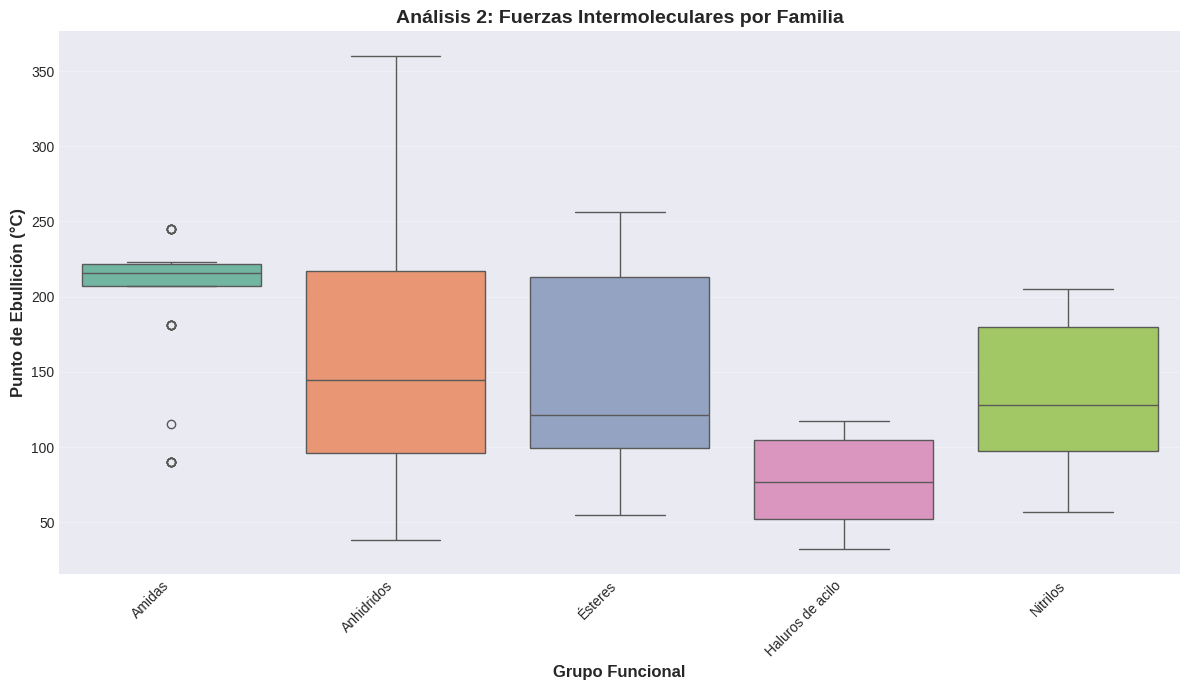


--------------------------------------------------
ESTADISTICAS POR GRUPO FUNCIONAL
--------------------------------------------------
  Amidas:
     - Mediana: 216°C
     - Media: 202°C
     - n = 60 compuestos
  Anhidridos:
     - Mediana: 144°C
     - Media: 161°C
     - n = 20 compuestos
  Ésteres:
     - Mediana: 121°C
     - Media: 142°C
     - n = 60 compuestos
  Haluros de acilo:
     - Mediana: 77°C
     - Media: 77°C
     - n = 60 compuestos
  Nitrilos:
     - Mediana: 128°C
     - Media: 133°C
     - n = 40 compuestos

--------------------------------------------------
CONCLUSION:
--------------------------------------------------
  Mayor punto de ebullición: Amidas (216°C)
  Los grupos con puentes de hidrógeno tienen PE más altos:
     - Amidas, ácidos carboxílicos, alcoholes
  Grupos con solo fuerzas de London tienen PE más bajos:
     - Alcanos, halogenuros de alquilo
  Grupos con dipolo-dipolo tienen PE intermedios:
     - Ésteres, cetonas, aldehídos


In [68]:
# ============================================
# ANALISIS 2: Boxplot por Grupo Funcional
# ============================================

print("\n" + "="*70)
print("ANALISIS 2: Fuerzas Intermoleculares por Familia")
print("="*70)

if 'Grupo Funcional' not in df.columns:
    print("ERROR: Columna 'Grupo Funcional' no encontrada")
    print(f"Columnas disponibles: {list(df.columns)}")
else:
    # Filtrar datos
    plot_df = df.dropna(subset=['Grupo Funcional', 'PE_Sustrato °C']).copy()
    plot_df = plot_df[(plot_df['PE_Sustrato °C'] >= PE_MIN) & (plot_df['PE_Sustrato °C'] <= PE_MAX)]
    plot_df = plot_df[~plot_df['Grupo Funcional'].isin(['nan', 'None', ''])]

    print(f"Compuestos después de filtrar: {len(plot_df)}")

    # Solo grupos con al menos 3 compuestos
    grupos_validos = plot_df['Grupo Funcional'].value_counts()
    grupos_validos = grupos_validos[grupos_validos >= 3].index
    plot_df = plot_df[plot_df['Grupo Funcional'].isin(grupos_validos)]

    print(f"Grupos funcionales analizados: {list(plot_df['Grupo Funcional'].unique())}")

    if len(plot_df) >= 5:
        # MODIFICABLE: Parámetros del gráfico
        FIG_SIZE = (12, 7)
        COLOR_PALETTE = 'Set2'    # Opciones: 'viridis', 'coolwarm', 'Blues', 'RdYlGn'
        ROTATION = 45             # Rotación de etiquetas: 0, 45, 90

        plt.figure(figsize=FIG_SIZE)

        # Crear boxplot
        sns.boxplot(
            x='Grupo Funcional',
            y='PE_Sustrato °C',
            data=plot_df,
            hue='Grupo Funcional',
            palette=COLOR_PALETTE,
            legend=False
        )

        # Formato de ejes
        plt.xticks(rotation=ROTATION, ha='right', fontsize=10)
        plt.xlabel('Grupo Funcional', fontsize=12, fontweight='bold')
        plt.ylabel('Punto de Ebullición (°C)', fontsize=12, fontweight='bold')
        plt.title('Análisis 2: Fuerzas Intermoleculares por Familia',
                 fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()

        # Mostrar estadísticas
        print("\n" + "-" * 50)
        print("ESTADISTICAS POR GRUPO FUNCIONAL")
        print("-" * 50)

        grupo_max = None
        mediana_max = -float('inf')

        for grupo in plot_df['Grupo Funcional'].unique():
            datos = plot_df[plot_df['Grupo Funcional'] == grupo]['PE_Sustrato °C']
            mediana = datos.median()
            media = datos.mean()
            print(f"  {grupo}:")
            print(f"     - Mediana: {mediana:.0f}°C")
            print(f"     - Media: {media:.0f}°C")
            print(f"     - n = {len(datos)} compuestos")

            if mediana > mediana_max:
                mediana_max = mediana
                grupo_max = grupo

        print("\n" + "-" * 50)
        print("CONCLUSION:")
        print("-" * 50)
        print(f"  Mayor punto de ebullición: {grupo_max} ({mediana_max:.0f}°C)")
        print("  Los grupos con puentes de hidrógeno tienen PE más altos:")
        print("     - Amidas, ácidos carboxílicos, alcoholes")
        print("  Grupos con solo fuerzas de London tienen PE más bajos:")
        print("     - Alcanos, halogenuros de alquilo")
        print("  Grupos con dipolo-dipolo tienen PE intermedios:")
        print("     - Ésteres, cetonas, aldehídos")
    else:
        print(f"Datos insuficientes: {len(plot_df)} compuestos (mínimo 5)")


ANALISIS 3: Acidez y Estabilidad por Resonancia


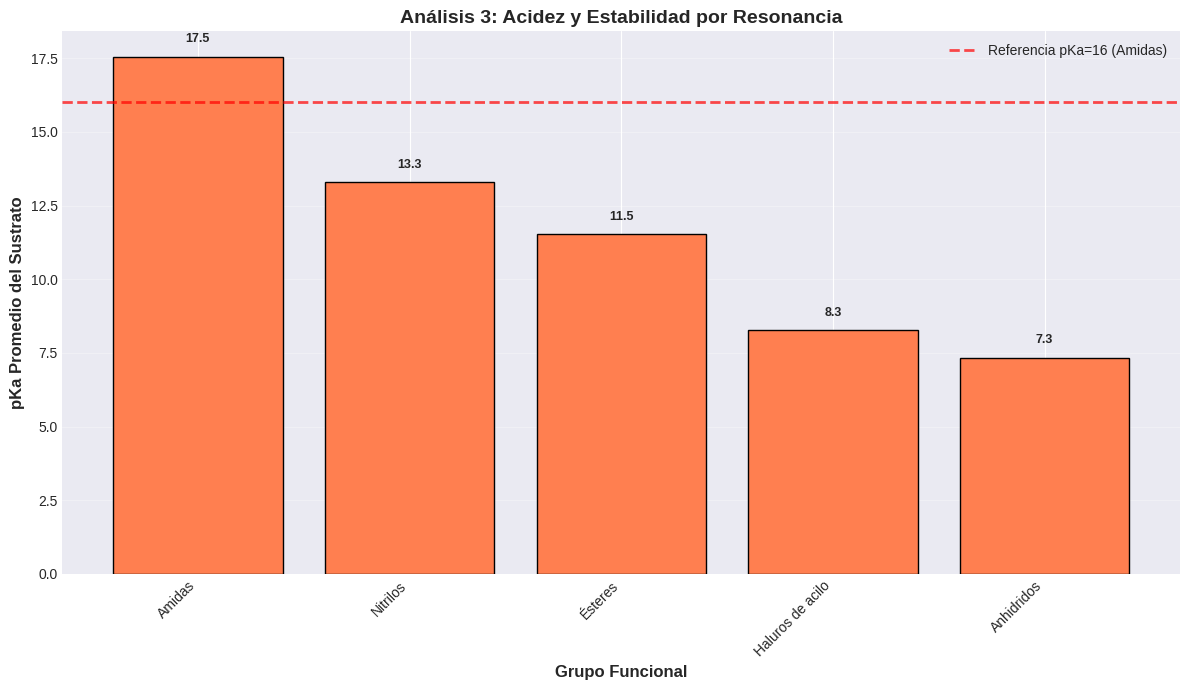


--------------------------------------------------
PKa PROMEDIO POR GRUPO FUNCIONAL
--------------------------------------------------
  Amidas: pKa = 17.5
  Nitrilos: pKa = 13.3
  Ésteres: pKa = 11.5
  Haluros de acilo: pKa = 8.3
  Anhidridos: pKa = 7.3

--------------------------------------------------
CONCLUSION:
--------------------------------------------------
  Las amidas tienen el pKa más alto (menos ácidas)
  Esto se debe a la deslocalización del par electrónico
  del nitrógeno en el grupo carbonilo
  La resonancia estabiliza la base conjugada


In [69]:
# ============================================
# ANALISIS 3: pKa por Grupo Funcional
# ============================================

print("\n" + "="*70)
print("ANALISIS 3: Acidez y Estabilidad por Resonancia")
print("="*70)

if 'pKa_Sustrato' not in df.columns:
    print("ERROR: Columna 'pKa_Sustrato' no encontrada")
else:
    # Filtrar datos
    plot_df = df.dropna(subset=['Grupo Funcional', 'pKa_Sustrato']).copy()
    plot_df = plot_df[(plot_df['pKa_Sustrato'] > 0) & (plot_df['pKa_Sustrato'] <= 50)]
    plot_df = plot_df[~plot_df['Grupo Funcional'].isin(['nan', 'None', ''])]

    # Solo grupos con al menos 2 compuestos
    grupos_validos = plot_df['Grupo Funcional'].value_counts()
    grupos_validos = grupos_validos[grupos_validos >= 2].index
    plot_df = plot_df[plot_df['Grupo Funcional'].isin(grupos_validos)]

    if len(plot_df) >= 4:
        # MODIFICABLE: Orden ascendente/descendente
        medias = plot_df.groupby('Grupo Funcional')['pKa_Sustrato'].mean().sort_values(ascending=False)

        # MODIFICABLE: Parámetros del gráfico
        FIG_SIZE = (12, 7)
        BAR_COLOR = 'coral'           # Opciones: 'skyblue', 'purple', 'darkgreen', '#FF5733'
        REFERENCE_Y = 16              # Línea de referencia (pKa de amidas)
        REFERENCE_COLOR = 'red'

        plt.figure(figsize=FIG_SIZE)

        # Gráfico de barras
        plt.bar(
            range(len(medias)),
            medias.values,
            color=BAR_COLOR,
            edgecolor='black',
            linewidth=1
        )

        plt.xticks(range(len(medias)), medias.index, rotation=45, ha='right')
        plt.xlabel('Grupo Funcional', fontsize=12, fontweight='bold')
        plt.ylabel('pKa Promedio del Sustrato', fontsize=12, fontweight='bold')
        plt.title('Análisis 3: Acidez y Estabilidad por Resonancia',
                 fontsize=14, fontweight='bold')

        # Línea de referencia
        plt.axhline(
            y=REFERENCE_Y,
            color=REFERENCE_COLOR,
            linestyle='--',
            alpha=0.7,
            linewidth=2,
            label=f'Referencia pKa={REFERENCE_Y} (Amidas)'
        )

        plt.legend()
        plt.grid(True, alpha=0.3, axis='y')

        # Añadir valores sobre las barras
        for i, v in enumerate(medias.values):
            plt.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

        plt.tight_layout()
        plt.show()

        # Mostrar resultados
        print("\n" + "-" * 50)
        print("PKa PROMEDIO POR GRUPO FUNCIONAL")
        print("-" * 50)
        for grupo in medias.index:
            print(f"  {grupo}: pKa = {medias[grupo]:.1f}")

        print("\n" + "-" * 50)
        print("CONCLUSION:")
        print("-" * 50)
        print("  Las amidas tienen el pKa más alto (menos ácidas)")
        print("  Esto se debe a la deslocalización del par electrónico")
        print("  del nitrógeno en el grupo carbonilo")
        print("  La resonancia estabiliza la base conjugada")
    else:
        print(f"Datos insuficientes: {len(plot_df)} compuestos (mínimo 4)")


ANALISIS 4: Evaluación de Riesgo Ambiental y Toxicidad


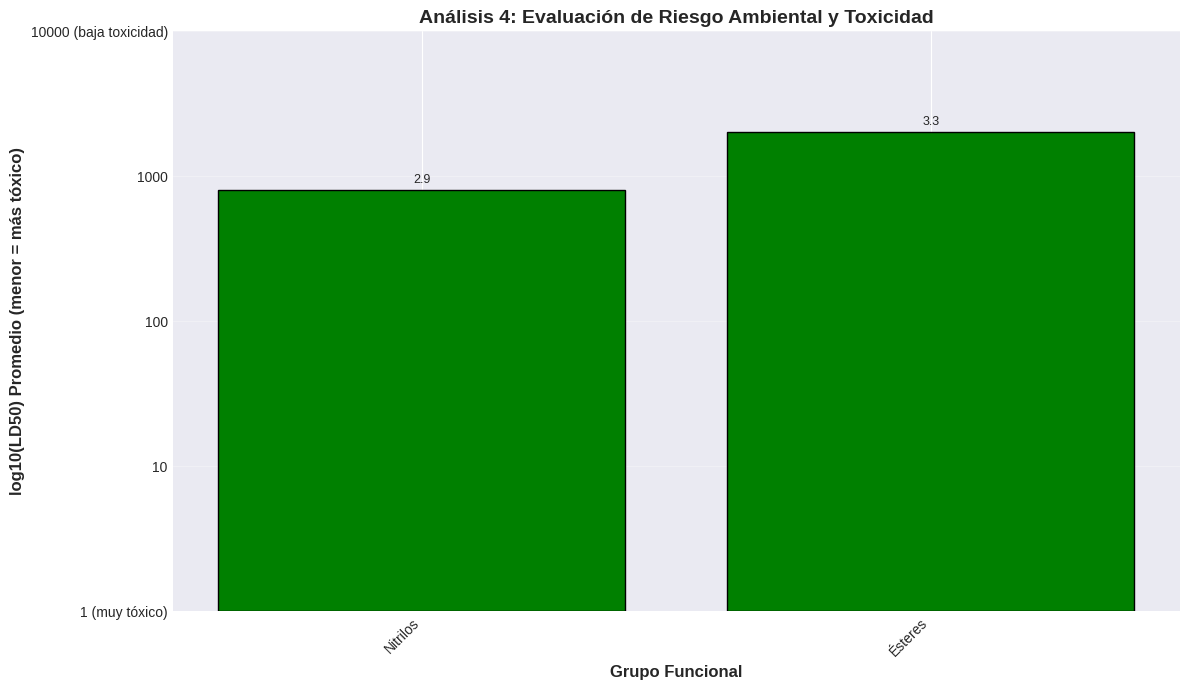


--------------------------------------------------
CLASIFICACION DE RIESGO POR GRUPO FUNCIONAL
--------------------------------------------------
  [+] Nitrilos: LD50 = 800.0 mg/kg -> BAJA TOXICIDAD
  [+] Ésteres: LD50 = 2014.2 mg/kg -> BAJA TOXICIDAD

--------------------------------------------------
CONCLUSION:
--------------------------------------------------
  La mayoría de los compuestos presentan baja toxicidad


In [70]:
# ============================================
# ANALISIS 4: Toxicidad LD50 por Grupo Funcional
# ============================================

print("\n" + "="*70)
print("ANALISIS 4: Evaluación de Riesgo Ambiental y Toxicidad")
print("="*70)

if 'LD50_Sustrato mg /kg' not in df.columns:
    print("ERROR: Columna 'LD50_Sustrato mg /kg' no encontrada")
else:
    # Filtrar datos
    plot_df = df.dropna(subset=['Grupo Funcional', 'LD50_Sustrato mg /kg']).copy()
    plot_df = plot_df[(plot_df['LD50_Sustrato mg /kg'] > 0.0001) & (plot_df['LD50_Sustrato mg /kg'] <= 5000)]
    plot_df = plot_df[~plot_df['Grupo Funcional'].isin(['nan', 'None', ''])]
    plot_df['log_LD50'] = np.log10(plot_df['LD50_Sustrato mg /kg'])

    # Solo grupos con al menos 2 compuestos
    grupos_validos = plot_df['Grupo Funcional'].value_counts()
    grupos_validos = grupos_validos[grupos_validos >= 2].index
    plot_df = plot_df[plot_df['Grupo Funcional'].isin(grupos_validos)]

    if len(plot_df) >= 4:
        medias = plot_df.groupby('Grupo Funcional')['log_LD50'].mean().sort_values()

        # MODIFICABLE: Umbrales de toxicidad
        # log10(50) = 1.7, log10(500) = 2.7
        UMBRAL_MUY_TOXICO = 1.7    # LD50 < 50 mg/kg
        UMBRAL_TOXICO = 2.7        # LD50 < 500 mg/kg

        # Colores según toxicidad
        colors = [
            'darkred' if v < UMBRAL_MUY_TOXICO
            else 'orange' if v < UMBRAL_TOXICO
            else 'green'
            for v in medias.values
        ]

        plt.figure(figsize=(12, 7))

        # Gráfico de barras
        plt.bar(range(len(medias)), medias.values, color=colors, edgecolor='black')
        plt.xticks(range(len(medias)), medias.index, rotation=45, ha='right')
        plt.xlabel('Grupo Funcional', fontsize=12, fontweight='bold')
        plt.ylabel('log10(LD50) Promedio (menor = más tóxico)', fontsize=12, fontweight='bold')
        plt.title('Análisis 4: Evaluación de Riesgo Ambiental y Toxicidad',
                 fontsize=14, fontweight='bold')

        # Etiquetas del eje Y con valores reales
        plt.yticks(
            [0, 1, 2, 3, 4],
            ['1 (muy tóxico)', '10', '100', '1000', '10000 (baja toxicidad)']
        )
        plt.grid(True, alpha=0.3, axis='y')

        # Añadir valores
        for i, v in enumerate(medias.values):
            plt.text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=9)

        plt.tight_layout()
        plt.show()

        # Mostrar clasificación de riesgo
        print("\n" + "-" * 50)
        print("CLASIFICACION DE RIESGO POR GRUPO FUNCIONAL")
        print("-" * 50)

        for grupo in medias.index:
            media_log = medias[grupo]
            ld50_aprox = 10**media_log

            # MODIFICABLE: Umbrales de clasificación
            if ld50_aprox < 50:
                riesgo = "EXTREMADAMENTE TOXICO"
                simbolo = "[!]"
            elif ld50_aprox < 500:
                riesgo = "TOXICO"
                simbolo = "[*]"
            else:
                riesgo = "BAJA TOXICIDAD"
                simbolo = "[+]"

            print(f"  {simbolo} {grupo}: LD50 = {ld50_aprox:.1f} mg/kg -> {riesgo}")

        print("\n" + "-" * 50)
        print("CONCLUSION:")
        print("-" * 50)
        if any(10**medias[g] < 50 for g in medias.index):
            print("  ALERTA: Se identificaron grupos funcionales extremadamente tóxicos")
            print("  Requieren protocolos de seguridad especiales")
        else:
            print("  La mayoría de los compuestos presentan baja toxicidad")
    else:
        print(f"Datos insuficientes: {len(plot_df)} compuestos (mínimo 4)")


ANALISIS 5: Distribución de la Muestra


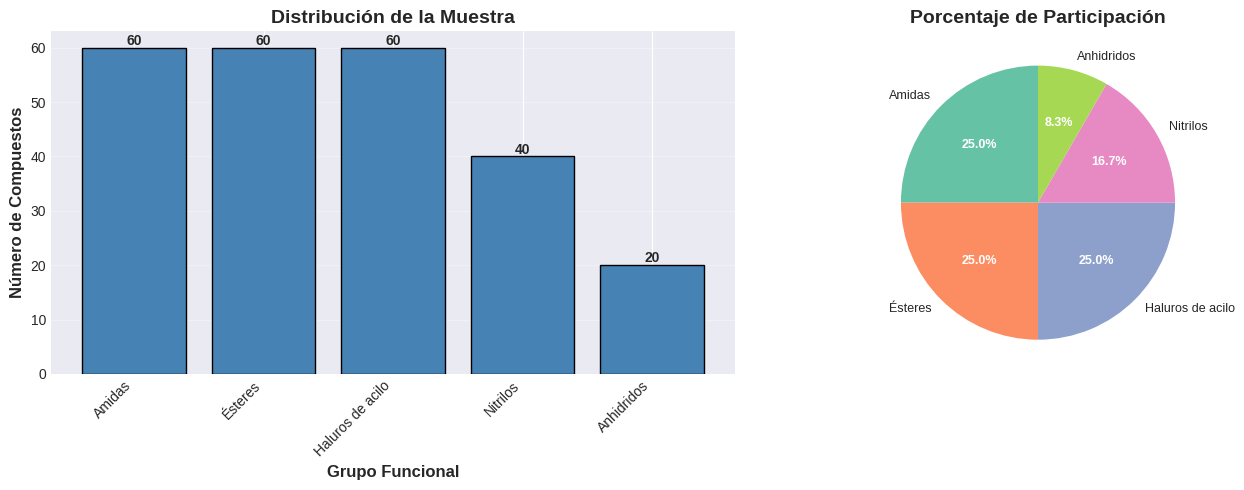


--------------------------------------------------
RESUMEN DE LA MUESTRA
--------------------------------------------------
Total de compuestos: 240
Número de grupos funcionales: 5
Grupo más representado: Amidas (60 compuestos, 25.0%)
Grupo menos representado: Anhidridos (20 compuestos, 8.3%)


In [71]:
# ============================================
# ANALISIS 5: Distribución de la Muestra
# ============================================

print("\n" + "="*70)
print("ANALISIS 5: Distribución de la Muestra")
print("="*70)

if 'Grupo Funcional' not in df.columns:
    print("ERROR: Columna 'Grupo Funcional' no encontrada")
else:
    plot_df = df.dropna(subset=['Grupo Funcional']).copy()
    plot_df = plot_df[~plot_df['Grupo Funcional'].isin(['nan', 'None', ''])]
    counts = plot_df['Grupo Funcional'].value_counts()

    # MODIFICABLE: Tamaño de la figura
    FIG_SIZE = (14, 5)
    BAR_COLOR = 'steelblue'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIG_SIZE)

    # Gráfico de barras (izquierda)
    ax1.bar(range(len(counts)), counts.values, color=BAR_COLOR, edgecolor='black')
    ax1.set_xticks(range(len(counts)))
    ax1.set_xticklabels(counts.index, rotation=45, ha='right')
    ax1.set_xlabel('Grupo Funcional', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Número de Compuestos', fontsize=12, fontweight='bold')
    ax1.set_title('Distribución de la Muestra', fontsize=14, fontweight='bold')

    # Añadir valores sobre las barras
    for i, v in enumerate(counts.values):
        ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

    ax1.grid(True, alpha=0.3, axis='y')

    # Gráfico de torta (derecha)
    # MODIFICABLE: startangle (0, 90, 180), autopct formato
    wedges, texts, autotexts = ax2.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 9}
    )

    # Personalizar texto de porcentajes
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    ax2.set_title('Porcentaje de Participación', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Mostrar resumen
    print("\n" + "-" * 50)
    print("RESUMEN DE LA MUESTRA")
    print("-" * 50)
    print(f"Total de compuestos: {len(plot_df)}")
    print(f"Número de grupos funcionales: {len(counts)}")
    print(f"Grupo más representado: {counts.index[0]} ({counts.iloc[0]} compuestos, {100*counts.iloc[0]/len(plot_df):.1f}%)")
    print(f"Grupo menos representado: {counts.index[-1]} ({counts.iloc[-1]} compuestos, {100*counts.iloc[-1]/len(plot_df):.1f}%)")


ANALISIS 6: Efecto del Mecanismo en el Producto


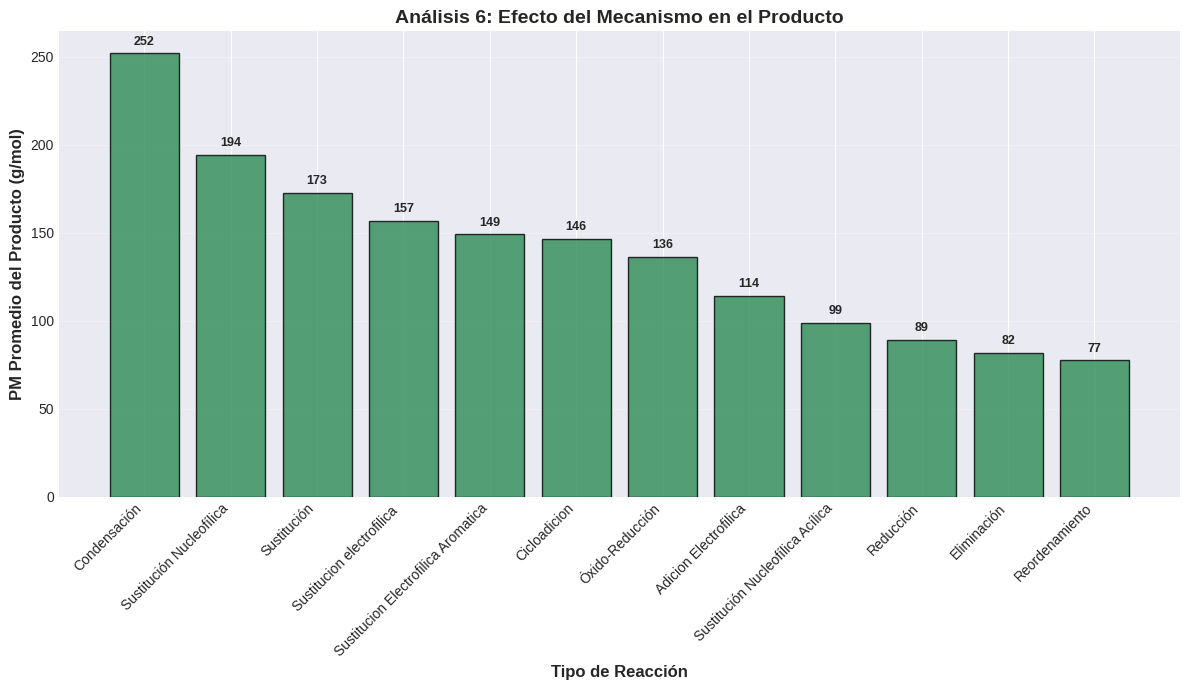


--------------------------------------------------
PM PROMEDIO POR TIPO DE REACCION
--------------------------------------------------
  Condensación: 252 g/mol
  Sustitución Nucleofílica: 194 g/mol
  Sustitución: 173 g/mol
  Sustitucion electrofilica : 157 g/mol
  Sustitucion Electrofilica Aromatica: 149 g/mol
  Cicloadicion: 146 g/mol
  Óxido-Reducción: 136 g/mol
  Adicion Electrofilica: 114 g/mol
  Sustitución Nucleofílica Acílica: 99 g/mol
  Reducción: 89 g/mol
  Eliminación: 82 g/mol
  Reordenamiento: 77 g/mol

--------------------------------------------------
CONCLUSION:
--------------------------------------------------
  Las reacciones de condensación generan productos más pesados


In [72]:
# ============================================
# ANALISIS 6: PM Producto por Tipo de Reacción
# ============================================

print("\n" + "="*70)
print("ANALISIS 6: Efecto del Mecanismo en el Producto")
print("="*70)

if 'Tipo_Reaccion' not in df.columns or 'PM_Producto' not in df.columns:
    print("ERROR: Columnas 'Tipo_Reaccion' o 'PM_Producto' no encontradas")
else:
    plot_df = df.dropna(subset=['Tipo_Reaccion', 'PM_Producto']).copy()
    plot_df = plot_df[(plot_df['PM_Producto'] > 0) & (plot_df['PM_Producto'] <= 600)]
    plot_df = plot_df[~plot_df['Tipo_Reaccion'].isin(['nan', 'None', ''])]

    # Solo tipos con al menos 3 reacciones
    tipos_validos = plot_df['Tipo_Reaccion'].value_counts()
    tipos_validos = tipos_validos[tipos_validos >= 3].index
    plot_df = plot_df[plot_df['Tipo_Reaccion'].isin(tipos_validos)]

    if len(plot_df) >= 5:
        medias = plot_df.groupby('Tipo_Reaccion')['PM_Producto'].mean().sort_values(ascending=False)

        # MODIFICABLE: Parámetros del gráfico
        FIG_SIZE = (12, 7)
        BAR_COLOR = 'seagreen'
        BAR_ALPHA = 0.8

        plt.figure(figsize=FIG_SIZE)

        plt.bar(
            range(len(medias)),
            medias.values,
            color=BAR_COLOR,
            edgecolor='black',
            alpha=BAR_ALPHA
        )

        plt.xticks(range(len(medias)), medias.index, rotation=45, ha='right')
        plt.xlabel('Tipo de Reacción', fontsize=12, fontweight='bold')
        plt.ylabel('PM Promedio del Producto (g/mol)', fontsize=12, fontweight='bold')
        plt.title('Análisis 6: Efecto del Mecanismo en el Producto',
                 fontsize=14, fontweight='bold')

        # Añadir valores
        for i, v in enumerate(medias.values):
            plt.text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')

        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

        # Mostrar resultados
        print("\n" + "-" * 50)
        print("PM PROMEDIO POR TIPO DE REACCION")
        print("-" * 50)
        for tipo in medias.index:
            print(f"  {tipo}: {medias[tipo]:.0f} g/mol")

        print("\n" + "-" * 50)
        print("CONCLUSION:")
        print("-" * 50)
        if medias.index[0] in ['Condensación', 'Polimerización']:
            print("  Las reacciones de condensación generan productos más pesados")
        if medias.index[-1] in ['Reducción', 'Hidrólisis']:
            print("  Las reacciones de reducción generan productos más ligeros")
    else:
        print(f"Datos insuficientes: {len(plot_df)} reacciones (mínimo 5)")


ANALISIS 7: Evaluación de Riesgo por Toxicidad de Solventes
Reacciones analizadas: 226


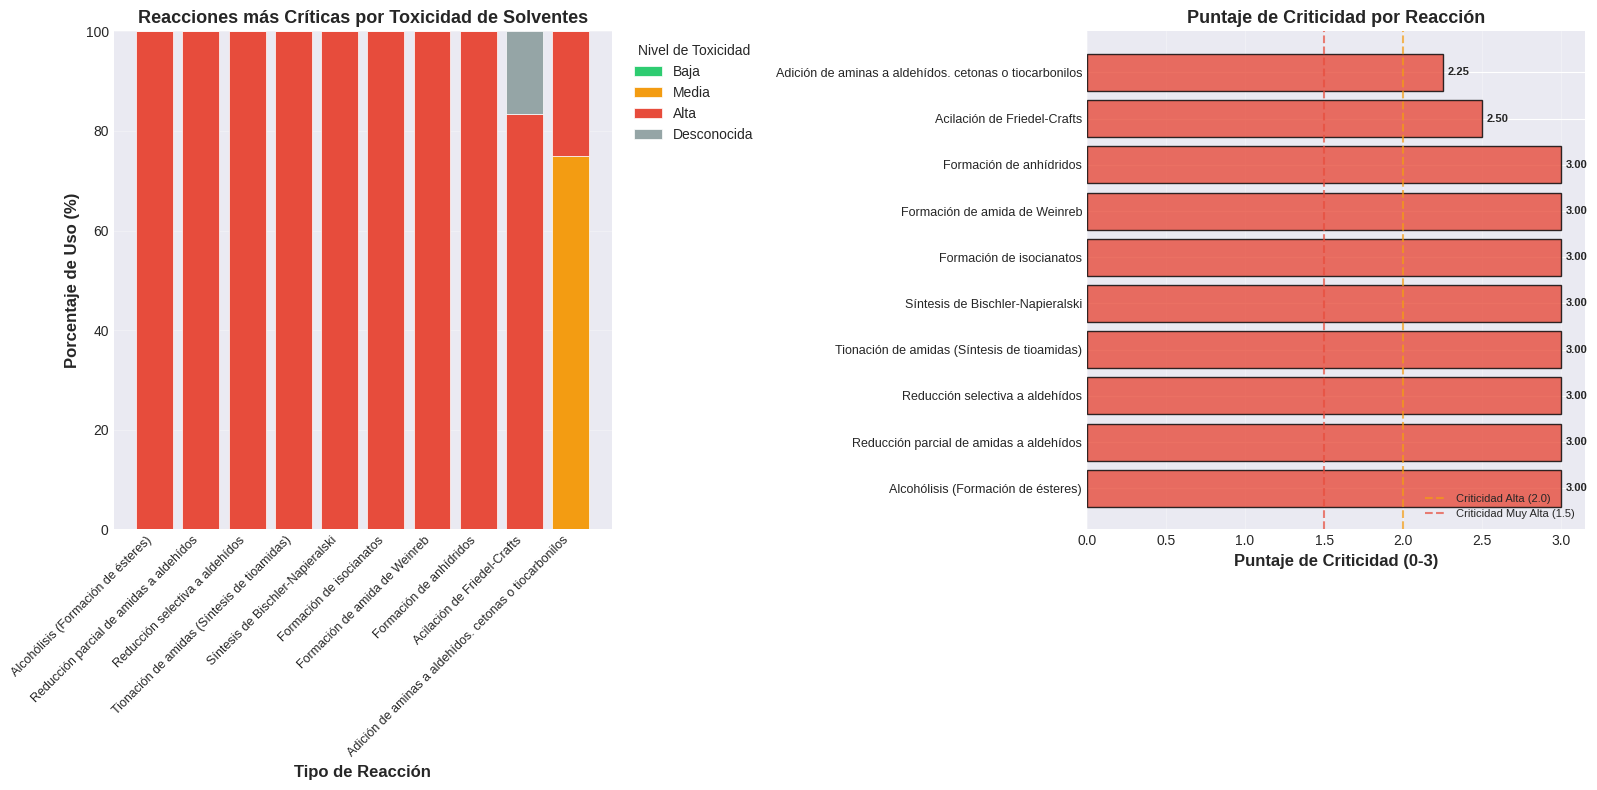


--------------------------------------------------
RANKING DE REACCIONES POR CRITICIDAD
--------------------------------------------------
  1. Alcohólisis (Formación de ésteres): Puntaje=3.00
  2. Reducción parcial de amidas a aldehídos: Puntaje=3.00
  3. Reducción selectiva a aldehídos: Puntaje=3.00
  4. Tionación de amidas (Síntesis de tioamidas): Puntaje=3.00
  5. Síntesis de Bischler-Napieralski: Puntaje=3.00
  6. Formación de isocianatos: Puntaje=3.00
  7. Formación de amida de Weinreb: Puntaje=3.00
  8. Formación de anhídridos: Puntaje=3.00
  9. Acilación de Friedel-Crafts: Puntaje=2.50
  10. Adición de aminas a aldehídos. cetonas o tiocarbonilos: Puntaje=2.25

ALERTA: Reacciones con uso de solventes de ALTA toxicidad >50%
  Alcohólisis (Formación de ésteres): 100.0%
  Reducción parcial de amidas a aldehídos: 100.0%
  Reducción selectiva a aldehídos: 100.0%
  Tionación de amidas (Síntesis de tioamidas): 100.0%
  Síntesis de Bischler-Napieralski: 100.0%
  Formación de isocianato

In [73]:
# ============================================
# ANALISIS 7: Criticidad de Solventes por Reacción
# ============================================

print("\n" + "="*70)
print("ANALISIS 7: Evaluación de Riesgo por Toxicidad de Solventes")
print("="*70)

# MODIFICABLE: Listas de solventes por toxicidad
SOLVENTES_ALTA_TOXICIDAD = [
    'benceno', 'c6h6', 'tolueno', 'c7h8', 'xileno', 'c8h10',
    'cloroformo', 'chcl3', 'diclorometano', 'ch2cl2', 'cloruro de metileno',
    'clorobenceno', '1.2-dicloroetano', 'c2h4cl2'
]

SOLVENTES_MEDIA_TOXICIDAD = [
    'eter', 'eter dietilico', 'c4h10o', 'thf', 'tetrahidrofurano', 'c4h8o', 'dioxano',
    'acetona', 'c3h6o', 'acetonitrilo', 'ch3cn', 'dmf', 'dimetilformamida', 'c3h7no',
    'hexano', 'c6h14', 'ciclohexano', 'c6h12'
]

SOLVENTES_BAJA_TOXICIDAD = [
    'agua', 'h2o', 'etanol', 'c2h6o', 'etoh', 'metanol', 'ch3oh', 'meoh', 'isopropanol'
]

def clasificar_toxicidad_solvente(solvente):
    """Clasifica un solvente en niveles de toxicidad"""
    s = str(solvente).lower().strip()
    if s in SOLVENTES_BAJA_TOXICIDAD:
        return 'Baja'
    elif s in SOLVENTES_MEDIA_TOXICIDAD:
        return 'Media'
    elif s in SOLVENTES_ALTA_TOXICIDAD:
        return 'Alta'
    else:
        return 'Desconocida'

if 'Nombre_Reaccion' not in df.columns or 'Nombre_Solvente 1' not in df.columns:
    print("ERROR: Columnas 'Nombre_Reaccion' o 'Nombre_Solvente 1' no encontradas")
else:
    plot_df = df.dropna(subset=['Nombre_Reaccion', 'Nombre_Solvente 1']).copy()

    # Limpieza
    plot_df = plot_df[~plot_df['Nombre_Solvente 1'].astype(str).str.contains('nan|None|0', na=False, case=False)]
    plot_df = plot_df[plot_df['Nombre_Solvente 1'].astype(str).str.strip() != '']
    plot_df = plot_df[plot_df['Nombre_Reaccion'].astype(str).str.strip() != '']

    # Clasificar
    plot_df.loc[:, 'Toxicidad_Solvente'] = plot_df['Nombre_Solvente 1'].apply(clasificar_toxicidad_solvente)

    print(f"Reacciones analizadas: {len(plot_df)}")

    # Calcular porcentajes
    toxicidad_por_reaccion = plot_df.groupby('Nombre_Reaccion')['Toxicidad_Solvente'].value_counts(normalize=True).unstack(fill_value=0) * 100

    # Asegurar categorías
    for nivel in ['Baja', 'Media', 'Alta', 'Desconocida']:
        if nivel not in toxicidad_por_reaccion.columns:
            toxicidad_por_reaccion[nivel] = 0

    # MODIFICABLE: Ponderaciones para criticidad
    PESO_ALTA = 3
    PESO_MEDIA = 2
    PESO_BAJA = 1

    toxicidad_por_reaccion['Puntaje_Criticidad'] = (
        toxicidad_por_reaccion['Alta'] * PESO_ALTA +
        toxicidad_por_reaccion['Media'] * PESO_MEDIA +
        toxicidad_por_reaccion['Baja'] * PESO_BAJA
    ) / 100

    toxicidad_por_reaccion = toxicidad_por_reaccion.sort_values('Puntaje_Criticidad', ascending=False)

    # Solo reacciones con al menos 2 ocurrencias
    conteo_reacciones = plot_df['Nombre_Reaccion'].value_counts()
    reacciones_validas = conteo_reacciones[conteo_reacciones >= 2].index
    toxicidad_por_reaccion = toxicidad_por_reaccion[toxicidad_por_reaccion.index.isin(reacciones_validas)]

    if len(toxicidad_por_reaccion) >= 2:
        # Colores para niveles de toxicidad
        COLORES_TOXICIDAD = {
            'Baja': '#2ecc71',      # Verde
            'Media': '#f39c12',     # Naranja
            'Alta': '#e74c3c',      # Rojo
            'Desconocida': '#95a5a6' # Gris
        }

        top_criticas = toxicidad_por_reaccion.head(10)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Gráfico 1: Barras apiladas
        bottom = np.zeros(len(top_criticas))
        for nivel, color in COLORES_TOXICIDAD.items():
            if nivel in top_criticas.columns:
                valores = top_criticas[nivel].values
                ax1.bar(
                    range(len(top_criticas)),
                    valores,
                    bottom=bottom,
                    color=color,
                    edgecolor='white',
                    linewidth=0.5,
                    label=nivel
                )
                bottom += valores

        ax1.set_xticks(range(len(top_criticas)))
        ax1.set_xticklabels(top_criticas.index, rotation=45, ha='right', fontsize=9)
        ax1.set_ylabel('Porcentaje de Uso (%)', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Tipo de Reacción', fontsize=12, fontweight='bold')
        ax1.set_title('Reacciones más Críticas por Toxicidad de Solventes',
                     fontsize=13, fontweight='bold')
        ax1.legend(title='Nivel de Toxicidad', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax1.set_ylim(0, 100)
        ax1.grid(True, alpha=0.3, axis='y')

        # Gráfico 2: Puntaje de criticidad
        puntajes = top_criticas['Puntaje_Criticidad'].values

        # Colores según criticidad
        CRITICO_ALTO = 2.0
        CRITICO_MEDIO = 1.5

        colores_criticos = [
            '#e74c3c' if p > CRITICO_ALTO
            else '#f39c12' if p > CRITICO_MEDIO
            else '#2ecc71'
            for p in puntajes
        ]

        bars = ax2.barh(
            range(len(top_criticas)),
            puntajes,
            color=colores_criticos,
            edgecolor='black',
            alpha=0.8
        )

        ax2.set_yticks(range(len(top_criticas)))
        ax2.set_yticklabels(top_criticas.index, fontsize=9)
        ax2.set_xlabel('Puntaje de Criticidad (0-3)', fontsize=12, fontweight='bold')
        ax2.set_title('Puntaje de Criticidad por Reacción', fontsize=13, fontweight='bold')
        ax2.axvline(
            x=CRITICO_ALTO,
            color='#f39c12',
            linestyle='--',
            alpha=0.7,
            linewidth=1.5,
            label=f'Criticidad Alta ({CRITICO_ALTO})'
        )
        ax2.axvline(
            x=CRITICO_MEDIO,
            color='#e74c3c',
            linestyle='--',
            alpha=0.7,
            linewidth=1.5,
            label=f'Criticidad Muy Alta ({CRITICO_MEDIO})'
        )
        ax2.legend(loc='lower right', fontsize=8)
        ax2.grid(True, alpha=0.3, axis='x')

        # Añadir valores
        for i, (bar, puntaje) in enumerate(zip(bars, puntajes)):
            ax2.text(
                bar.get_width() + 0.03,
                bar.get_y() + bar.get_height()/2,
                f'{puntaje:.2f}',
                va='center',
                fontsize=8,
                fontweight='bold'
            )

        plt.tight_layout()
        plt.show()

        # Mostrar ranking
        print("\n" + "-" * 50)
        print("RANKING DE REACCIONES POR CRITICIDAD")
        print("-" * 50)
        for i, (reaccion, row) in enumerate(top_criticas.iterrows(), 1):
            print(f"  {i}. {reaccion}: Puntaje={row['Puntaje_Criticidad']:.2f}")

        # Alertas
        peligrosas = top_criticas[top_criticas['Alta'] > 50]
        if len(peligrosas) > 0:
            print("\n" + "=" * 30)
            print("ALERTA: Reacciones con uso de solventes de ALTA toxicidad >50%")
            print("=" * 30)
            for reaccion in peligrosas.index:
                print(f"  {reaccion}: {peligrosas.loc[reaccion, 'Alta']:.1f}%")
    else:
        print(f"Datos insuficientes: {len(toxicidad_por_reaccion)} reacciones válidas")


ANALISIS 8: Clasificación Ecológica de Solventes
Reacciones analizadas: 148
Tipos de reacción: ['Reordenamiento', 'Cicloadicion', 'Sustitución Nucleofílica', 'Condensación', 'Eliminación', 'Reducción', 'Sustitución Nucleofílica Acílica', 'Sustitucion electrofilica ', 'Sustitución', 'Sustitucion Electrofilica Aromatica', 'Adicion Electrofilica']


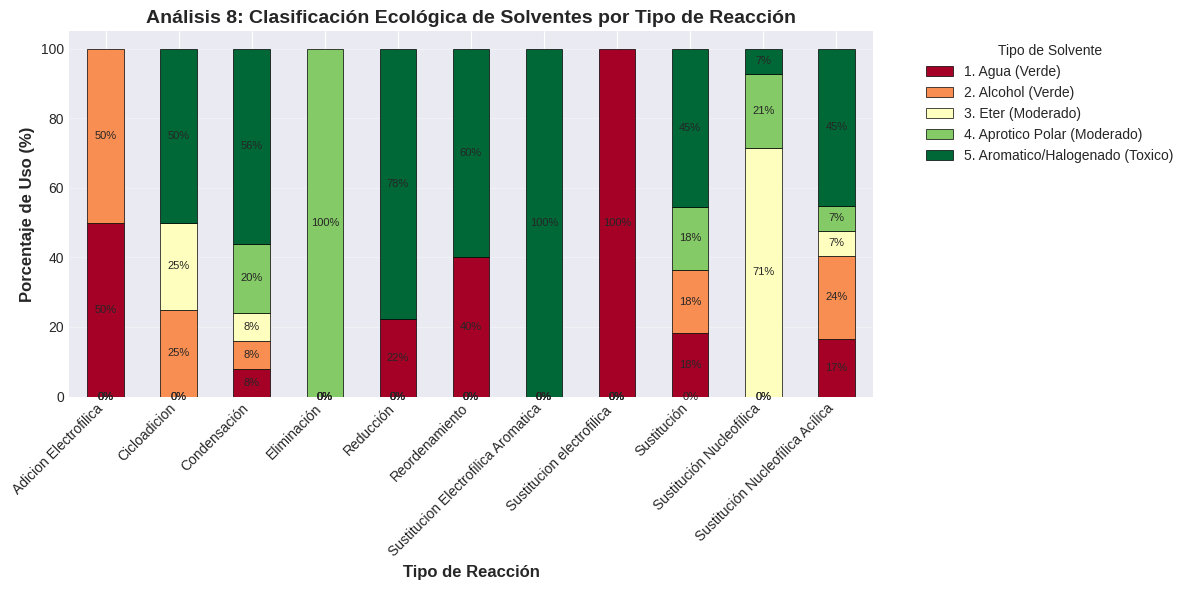


--------------------------------------------------
PREFERENCIA DE SOLVENTES POR TIPO DE REACCION
--------------------------------------------------
  Adicion Electrofilica: Principalmente 1. Agua (Verde) (50%)
  Cicloadicion: Principalmente 5. Aromatico/Halogenado (Toxico) (50%)
  Condensación: Principalmente 5. Aromatico/Halogenado (Toxico) (56%)
  Eliminación: Principalmente 4. Aprotico Polar (Moderado) (100%)
  Reducción: Principalmente 5. Aromatico/Halogenado (Toxico) (78%)
  Reordenamiento: Principalmente 5. Aromatico/Halogenado (Toxico) (60%)
  Sustitucion Electrofilica Aromatica: Principalmente 5. Aromatico/Halogenado (Toxico) (100%)
  Sustitucion electrofilica : Principalmente 1. Agua (Verde) (100%)
  Sustitución: Principalmente 5. Aromatico/Halogenado (Toxico) (45%)
  Sustitución Nucleofílica: Principalmente 3. Eter (Moderado) (71%)
  Sustitución Nucleofílica Acílica: Principalmente 5. Aromatico/Halogenado (Toxico) (45%)

--------------------------------------------------
REA

In [74]:
# ============================================
# ANALISIS 8: Clasificación Ecológica de Solventes
# ============================================

print("\n" + "="*70)
print("ANALISIS 8: Clasificación Ecológica de Solventes")
print("="*70)

def clasificar_solvente_ecologico(solvente):
    """Clasifica un solvente según su impacto ecológico"""
    solvente = str(solvente).lower().strip()

    # MODIFICABLE: Añadir o modificar categorías
    if solvente in ['agua', 'h2o']:
        return '1. Agua (Verde)'
    elif solvente in ['etanol', 'c2h6o', 'etoh', 'metanol', 'ch3oh', 'meoh', 'isopropanol']:
        return '2. Alcohol (Verde)'
    elif solvente in ['eter', 'eter dietilico', 'c4h10o', 'thf', 'tetrahidrofurano', 'c4h8o']:
        return '3. Eter (Moderado)'
    elif solvente in ['acetona', 'c3h6o', 'acetonitrilo', 'ch3cn', 'dmf', 'dimetilformamida']:
        return '4. Aprotico Polar (Moderado)'
    elif solvente in ['benceno', 'c6h6', 'tolueno', 'c7h8', 'xileno', 'c8h10',
                      'cloroformo', 'chcl3', 'diclorometano', 'ch2cl2']:
        return '5. Aromatico/Halogenado (Toxico)'
    else:
        return '6. Otros'

if 'Tipo_Reaccion' not in df.columns or 'Nombre_Solvente 1' not in df.columns:
    print("ERROR: Columnas 'Tipo_Reaccion' o 'Nombre_Solvente 1' no encontradas")
else:
    plot_df = df.dropna(subset=['Tipo_Reaccion', 'Nombre_Solvente 1']).copy()

    plot_df.loc[:, 'Tipo_Solvente'] = plot_df['Nombre_Solvente 1'].apply(clasificar_solvente_ecologico)
    plot_df = plot_df[~plot_df['Tipo_Solvente'].isin(['6. Otros'])]

    # Solo tipos con al menos 3 reacciones
    tipos_validos = plot_df['Tipo_Reaccion'].value_counts()
    tipos_validos = tipos_validos[tipos_validos >= 3].index
    plot_df = plot_df[plot_df['Tipo_Reaccion'].isin(tipos_validos)]

    print(f"Reacciones analizadas: {len(plot_df)}")
    print(f"Tipos de reacción: {list(plot_df['Tipo_Reaccion'].unique())}")

    if len(plot_df) >= 5:
        # Tabla cruzada de porcentajes
        cross_tab = pd.crosstab(
            plot_df['Tipo_Reaccion'],
            plot_df['Tipo_Solvente'],
            normalize='index'
        ) * 100

        # Orden de columnas
        ORDEN_COLUMNAS = [
            '1. Agua (Verde)',
            '2. Alcohol (Verde)',
            '3. Eter (Moderado)',
            '4. Aprotico Polar (Moderado)',
            '5. Aromatico/Halogenado (Toxico)'
        ]

        columnas_existentes = [col for col in ORDEN_COLUMNAS if col in cross_tab.columns]
        cross_tab = cross_tab[columnas_existentes]

        # MODIFICABLE: colormap para el gráfico
        COLORMAP = 'RdYlGn'  # Opciones: 'viridis', 'coolwarm', 'Blues', 'Set2'

        ax = cross_tab.plot(
            kind='bar',
            stacked=True,
            figsize=(12, 6),
            colormap=COLORMAP,
            edgecolor='black',
            linewidth=0.5
        )

        plt.xlabel('Tipo de Reacción', fontsize=12, fontweight='bold')
        plt.ylabel('Porcentaje de Uso (%)', fontsize=12, fontweight='bold')
        plt.title('Análisis 8: Clasificación Ecológica de Solventes por Tipo de Reacción',
                 fontsize=14, fontweight='bold')
        plt.legend(title='Tipo de Solvente', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, alpha=0.3, axis='y')

        # Añadir valores en las barras
        for container in ax.containers:
            ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8)

        plt.tight_layout()
        plt.show()

        # Mostrar resultados
        print("\n" + "-" * 50)
        print("PREFERENCIA DE SOLVENTES POR TIPO DE REACCION")
        print("-" * 50)
        for tipo in cross_tab.index:
            solvente_principal = cross_tab.loc[tipo].idxmax()
            pct_max = cross_tab.loc[tipo].max()
            print(f"  {tipo}: Principalmente {solvente_principal} ({pct_max:.0f}%)")

        # Calcular porcentaje de solventes verdes
        cross_tab['Porcentaje_Verde'] = 0
        if '1. Agua (Verde)' in cross_tab.columns:
            cross_tab['Porcentaje_Verde'] += cross_tab['1. Agua (Verde)']
        if '2. Alcohol (Verde)' in cross_tab.columns:
            cross_tab['Porcentaje_Verde'] += cross_tab['2. Alcohol (Verde)']

        print("\n" + "-" * 50)
        print("REACCIONES MAS ECOLOGICAS")
        print("-" * 50)
        for tipo in cross_tab.nlargest(3, 'Porcentaje_Verde').index:
            verde_pct = cross_tab.loc[tipo, 'Porcentaje_Verde']
            print(f"  {tipo}: {verde_pct:.0f}% solventes verdes")
    else:
        print(f"Datos insuficientes: {len(plot_df)} reacciones (mínimo 5)")


ANALISIS 9: Cambio de Acidez en la Reacción


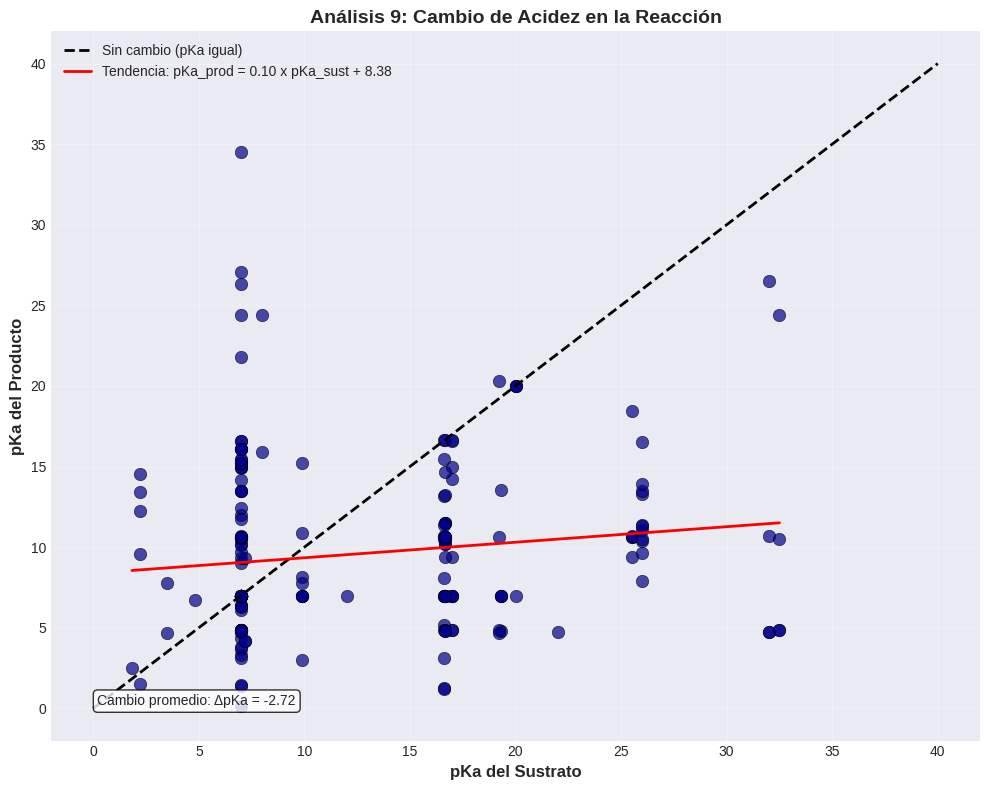


--------------------------------------------------
RESULTADOS DEL ANALISIS DE PKA
--------------------------------------------------
Cambio promedio de pKa: -2.72
Número de reacciones analizadas: 224

--------------------------------------------------
CONCLUSION:
--------------------------------------------------
  Los productos son MÁS ácidos que los sustratos
  El pKa disminuye -> se vuelven más ácidos


In [75]:
# ============================================
# ANALISIS 9: Cambio de Acidez en la Reacción
# ============================================

print("\n" + "="*70)
print("ANALISIS 9: Cambio de Acidez en la Reacción")
print("="*70)

if 'pKa_Sustrato' not in df.columns or 'pKa_Producto' not in df.columns:
    print("ERROR: Columnas 'pKa_Sustrato' o 'pKa_Producto' no encontradas")
else:
    plot_df = df.dropna(subset=['pKa_Sustrato', 'pKa_Producto']).copy()

    # MODIFICABLE: Rangos de pKa
    PKA_MIN, PKA_MAX = 0, 40

    plot_df = plot_df[
        (plot_df['pKa_Sustrato'] > PKA_MIN) & (plot_df['pKa_Sustrato'] <= PKA_MAX) &
        (plot_df['pKa_Producto'] > PKA_MIN) & (plot_df['pKa_Producto'] <= PKA_MAX)
    ]
    plot_df['Delta'] = plot_df['pKa_Producto'] - plot_df['pKa_Sustrato']

    if len(plot_df) >= 3:
        # MODIFICABLE: Parámetros del gráfico
        FIG_SIZE = (10, 8)
        POINT_COLOR = 'darkblue'
        POINT_ALPHA = 0.7
        POINT_SIZE = 80

        plt.figure(figsize=FIG_SIZE)

        # Gráfico de dispersión
        plt.scatter(
            plot_df['pKa_Sustrato'],
            plot_df['pKa_Producto'],
            alpha=POINT_ALPHA,
            s=POINT_SIZE,
            c=POINT_COLOR,
            edgecolors='black',
            linewidth=0.5
        )

        # Línea de identidad (sin cambio)
        plt.plot(
            [PKA_MIN, PKA_MAX],
            [PKA_MIN, PKA_MAX],
            'k--',
            linewidth=2,
            label='Sin cambio (pKa igual)'
        )

        # Línea de tendencia
        if len(plot_df) >= 4:
            z = np.polyfit(plot_df['pKa_Sustrato'], plot_df['pKa_Producto'], 1)
            x_line = np.linspace(plot_df['pKa_Sustrato'].min(), plot_df['pKa_Sustrato'].max(), 100)
            plt.plot(
                x_line,
                np.poly1d(z)(x_line),
                'r-',
                linewidth=2,
                label=f'Tendencia: pKa_prod = {z[0]:.2f} x pKa_sust + {z[1]:.2f}'
            )

        plt.xlabel('pKa del Sustrato', fontsize=12, fontweight='bold')
        plt.ylabel('pKa del Producto', fontsize=12, fontweight='bold')
        plt.title('Análisis 9: Cambio de Acidez en la Reacción',
                 fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Anotar el cambio promedio
        delta_mean = plot_df['Delta'].mean()
        plt.annotate(
            f'Cambio promedio: ΔpKa = {delta_mean:.2f}',
            xy=(0.05, 0.05),
            xycoords='axes fraction',
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
        )

        plt.tight_layout()
        plt.show()

        # Mostrar resultados
        print("\n" + "-" * 50)
        print("RESULTADOS DEL ANALISIS DE PKA")
        print("-" * 50)
        print(f"Cambio promedio de pKa: {delta_mean:.2f}")
        print(f"Número de reacciones analizadas: {len(plot_df)}")

        print("\n" + "-" * 50)
        print("CONCLUSION:")
        print("-" * 50)
        if delta_mean > 0:
            print("  Los productos son MENOS ácidos que los sustratos")
            print("  El pKa aumenta -> se vuelven más básicos")
        else:
            print("  Los productos son MÁS ácidos que los sustratos")
            print("  El pKa disminuye -> se vuelven más ácidos")
    else:
        print(f"Datos insuficientes: {len(plot_df)} reacciones (mínimo 3)")


ANALISIS 10: Catalizadores Más Utilizados


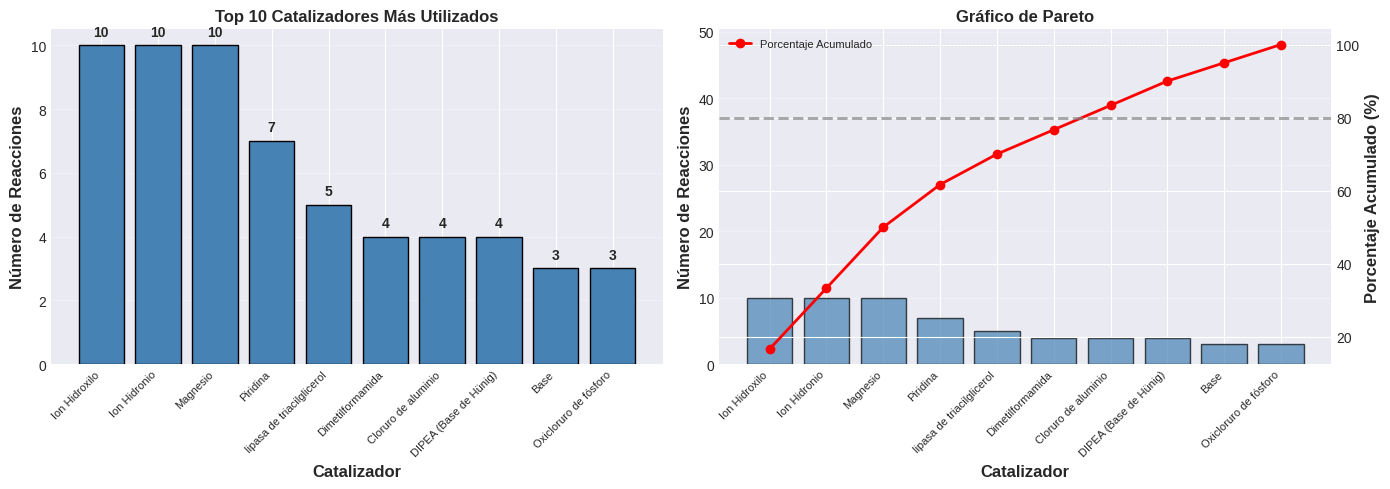


--------------------------------------------------
ESTADISTICAS DE CATALIZADORES
--------------------------------------------------
Total de reacciones con catalizador: 101
Catalizador más usado: Ion Hidroxilo
   -> 10 reacciones (9.9%)
Segundo catalizador: Ion Hidronio
   -> 10 reacciones (9.9%)
Tercer catalizador: Magnesio
   -> 10 reacciones (9.9%)

Top 3 concentra el 29.7% de las reacciones

Principio de Pareto: 10 catalizadores cubren el 80% de las reacciones
Diversidad: Se han utilizado 38 catalizadores diferentes

--------------------------------------------------
CONCLUSION:
--------------------------------------------------
  Buena diversidad de catalizadores
  -> Menor riesgo de dependencia


In [76]:
# ============================================
# ANALISIS 10: Catalizadores Más Utilizados (Pareto)
# ============================================

print("\n" + "="*70)
print("ANALISIS 10: Catalizadores Más Utilizados")
print("="*70)

if 'Nombre_Catalizador 1' not in df.columns:
    print("ERROR: Columna 'Nombre_Catalizador 1' no encontrada")
else:
    plot_df = df.dropna(subset=['Nombre_Catalizador 1']).copy()
    plot_df = plot_df[~plot_df['Nombre_Catalizador 1'].astype(str).str.contains('nan', na=False)]
    plot_df['Catalizador'] = plot_df['Nombre_Catalizador 1'].str.split(';').str[0].str.strip()

    # MODIFICABLE: Número de catalizadores a mostrar
    TOP_N = 10  # Cambiar a 5, 15, 20 según necesidad

    counts = plot_df['Catalizador'].value_counts().head(TOP_N)

    if len(counts) >= 2:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # ==========================================
        # Gráfico 1: Barras (Izquierda)
        # ==========================================
        BAR_COLOR = 'steelblue'

        ax1.bar(range(len(counts)), counts.values, color=BAR_COLOR, edgecolor='black')
        ax1.set_xticks(range(len(counts)))
        ax1.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
        ax1.set_xlabel('Catalizador', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Número de Reacciones', fontsize=12, fontweight='bold')
        ax1.set_title(f'Top {TOP_N} Catalizadores Más Utilizados', fontsize=12, fontweight='bold')

        # Añadir valores sobre las barras
        for i, v in enumerate(counts.values):
            ax1.text(i, v + 0.3, str(v), ha='center', fontweight='bold')

        ax1.grid(True, alpha=0.3, axis='y')

        # ==========================================
        # Gráfico 2: Pareto (Derecha)
        # ==========================================
        porcentajes_acumulados = counts.cumsum() / counts.sum() * 100

        # Barras
        ax2.bar(range(len(counts)), counts.values, color=BAR_COLOR, alpha=0.7, edgecolor='black')
        ax2.set_xticks(range(len(counts)))
        ax2.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
        ax2.set_xlabel('Catalizador', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Número de Reacciones', fontsize=12, fontweight='bold')
        ax2.set_title('Gráfico de Pareto', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')

        # Eje secundario para porcentaje acumulado
        ax2_twin = ax2.twinx()

        # CORREGIDO: Guardar la línea para la leyenda
        line, = ax2_twin.plot(
            range(len(counts)),
            porcentajes_acumulados,
            'r-o',
            linewidth=2,
            markersize=6,
            label='Porcentaje Acumulado'
        )

        ax2_twin.set_ylabel('Porcentaje Acumulado (%)', fontsize=12, fontweight='bold')

        # MODIFICABLE: Línea del 80% (Principio de Pareto)
        PARETO_LINE = 80
        ax2_twin.axhline(
            y=PARETO_LINE,
            color='gray',
            linestyle='--',
            alpha=0.7,
            linewidth=2,
            label=f'{PARETO_LINE}% Pareto'
        )

        # CORREGIDO: Leyenda con los elementos correctos
        ax2_twin.legend(handles=[line], loc='upper left', fontsize=8)

        # Línea de referencia en eje izquierdo
        ax2.axhline(y=counts.sum() * PARETO_LINE / 100, color='gray', linestyle=':', alpha=0.5, linewidth=1)

        plt.tight_layout()
        plt.show()

        # ==========================================
        # Resultados estadísticos
        # ==========================================
        print("\n" + "-" * 50)
        print("ESTADISTICAS DE CATALIZADORES")
        print("-" * 50)
        print(f"Total de reacciones con catalizador: {len(plot_df)}")
        print(f"Catalizador más usado: {counts.index[0]}")
        print(f"   -> {counts.iloc[0]} reacciones ({100*counts.iloc[0]/len(plot_df):.1f}%)")

        if len(counts) >= 2:
            print(f"Segundo catalizador: {counts.index[1]}")
            print(f"   -> {counts.iloc[1]} reacciones ({100*counts.iloc[1]/len(plot_df):.1f}%)")

        if len(counts) >= 3:
            print(f"Tercer catalizador: {counts.index[2]}")
            print(f"   -> {counts.iloc[2]} reacciones ({100*counts.iloc[2]/len(plot_df):.1f}%)")

        top3_pct = 100 * counts.head(3).sum() / len(plot_df)
        print(f"\nTop 3 concentra el {top3_pct:.1f}% de las reacciones")

        # Verificar principio de Pareto (80/20)
        acumulado = 0
        num_catalizadores = 0
        for i, v in enumerate(counts.values):
            acumulado += v
            num_catalizadores += 1
            if acumulado / len(plot_df) >= PARETO_LINE / 100:
                break

        print(f"\nPrincipio de Pareto: {num_catalizadores} catalizadores cubren el {PARETO_LINE}% de las reacciones")

        # Diversidad de catalizadores
        n_catalizadores = len(plot_df['Catalizador'].unique())
        print(f"Diversidad: Se han utilizado {n_catalizadores} catalizadores diferentes")

        print("\n" + "-" * 50)
        print("CONCLUSION:")
        print("-" * 50)
        if num_catalizadores <= 3:
            print("  Alta concentración de reacciones en pocos catalizadores")
            print("  -> Riesgo de dependencia en catalizadores específicos")
        else:
            print("  Buena diversidad de catalizadores")
            print("  -> Menor riesgo de dependencia")

    else:
        print(f"Datos insuficientes: {len(counts)} catalizadores (mínimo 2)")


ANALISIS 11C: Perfil de Toxicidad de la Base de Datos


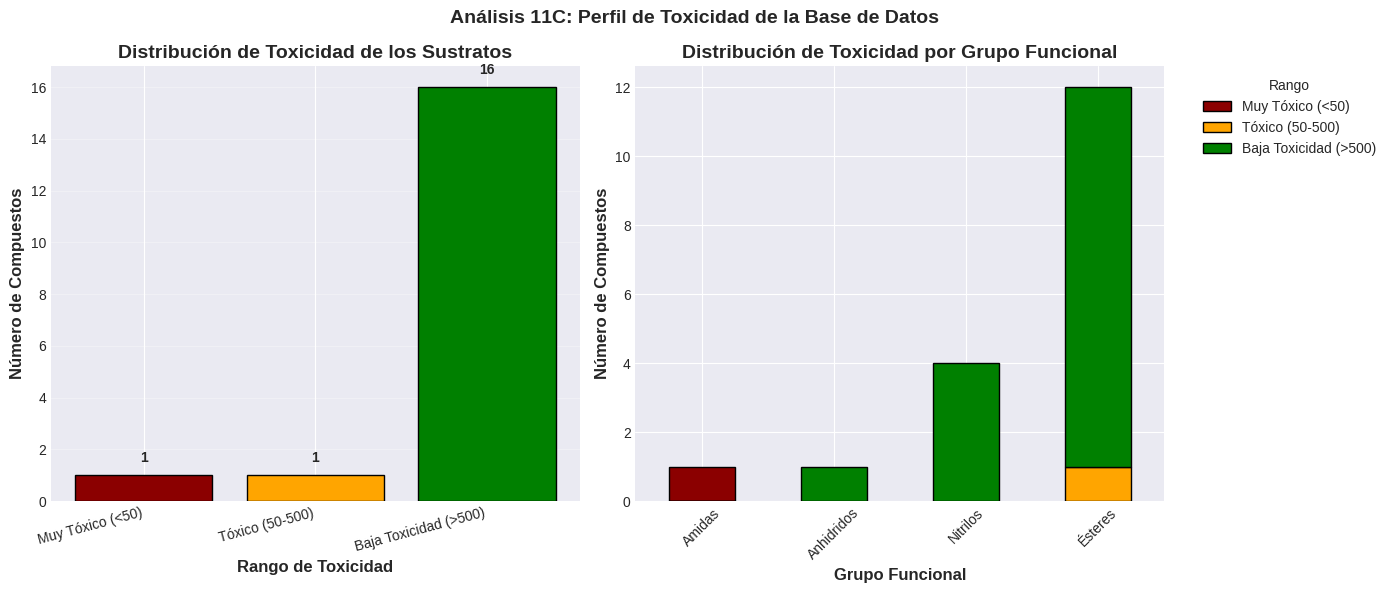


RESUMEN DE TOXICIDAD DE LA BASE DE DATOS

Total de compuestos con datos de LD50: 18

Distribución por rango:
  Muy Tóxico (<50): 1 compuestos (5.6%)
  Tóxico (50-500): 1 compuestos (5.6%)
  Baja Toxicidad (>500): 16 compuestos (88.9%)

Grupos funcionales más peligrosos:
  Amidas: 1 compuestos extremadamente tóxicos

CONCLUSION
Se identificaron 1 compuestos EXTREMADAMENTE TOXICOS
  -> Requieren protocolos de seguridad especiales


In [78]:
# ============================================
# ANALISIS 11C: Perfil de Toxicidad de la Base de Datos
# ============================================

print("\n" + "="*70)
print("ANALISIS 11C: Perfil de Toxicidad de la Base de Datos")
print("="*70)

if 'LD50_Sustrato mg /kg' not in df.columns:
    print("ERROR: Columna 'LD50_Sustrato mg /kg' no encontrada")
else:
    plot_df = df.dropna(subset=['LD50_Sustrato mg /kg']).copy()
    plot_df = plot_df[(plot_df['LD50_Sustrato mg /kg'] > 0.0001) & (plot_df['LD50_Sustrato mg /kg'] <= 5000)]

    # MODIFICABLE: Umbrales de clasificación
    UMBRAL_MUY_TOXICO = 50      # LD50 < 50 mg/kg
    UMBRAL_TOXICO = 500         # LD50 < 500 mg/kg

    def clasificar_ld50(ld50):
        if ld50 < UMBRAL_MUY_TOXICO:
            return 'Muy Tóxico (<50)'
        elif ld50 < UMBRAL_TOXICO:
            return 'Tóxico (50-500)'
        else:
            return 'Baja Toxicidad (>500)'

    plot_df['Rango_Toxicidad'] = plot_df['LD50_Sustrato mg /kg'].apply(clasificar_ld50)

    # Contar por rango
    conteo_rangos = plot_df['Rango_Toxicidad'].value_counts()
    orden_rangos = ['Muy Tóxico (<50)', 'Tóxico (50-500)', 'Baja Toxicidad (>500)']
    conteo_rangos = conteo_rangos.reindex(orden_rangos)

    # MODIFICABLE: Colores para cada rango
    COLORES_RANGOS = {
        'Muy Tóxico (<50)': 'darkred',
        'Tóxico (50-500)': 'orange',
        'Baja Toxicidad (>500)': 'green'
    }

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # ==========================================
    # Gráfico 1: Barras por rango de toxicidad
    # ==========================================
    colores_barra = [COLORES_RANGOS[r] for r in conteo_rangos.index if r in COLORES_RANGOS]
    ax1.bar(range(len(conteo_rangos)), conteo_rangos.values, color=colores_barra, edgecolor='black')
    ax1.set_xticks(range(len(conteo_rangos)))
    ax1.set_xticklabels(conteo_rangos.index, rotation=15, ha='right')
    ax1.set_xlabel('Rango de Toxicidad', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Número de Compuestos', fontsize=12, fontweight='bold')
    ax1.set_title('Distribución de Toxicidad de los Sustratos', fontsize=14, fontweight='bold')

    # Añadir valores
    for i, v in enumerate(conteo_rangos.values):
        ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

    ax1.grid(True, alpha=0.3, axis='y')

    # ==========================================
    # Gráfico 2: Proporción por grupo funcional
    # ==========================================
    if 'Grupo Funcional' in df.columns:
        plot_df_grupo = plot_df.groupby(['Grupo Funcional', 'Rango_Toxicidad']).size().unstack(fill_value=0)
        plot_df_grupo = plot_df_grupo[orden_rangos]
        plot_df_grupo = plot_df_grupo[plot_df_grupo.sum(axis=1) > 0]

        if len(plot_df_grupo) > 0:
            plot_df_grupo.plot(kind='bar', stacked=True, ax=ax2, color=COLORES_RANGOS, edgecolor='black')
            ax2.set_xlabel('Grupo Funcional', fontsize=12, fontweight='bold')
            ax2.set_ylabel('Número de Compuestos', fontsize=12, fontweight='bold')
            ax2.set_title('Distribución de Toxicidad por Grupo Funcional', fontsize=14, fontweight='bold')
            ax2.legend(title='Rango', bbox_to_anchor=(1.05, 1))
            ax2.tick_params(axis='x', rotation=45)
        else:
            ax2.text(0.5, 0.5, 'No hay datos suficientes por grupo funcional',
                    ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title('Distribución por Grupo Funcional', fontsize=14)
    else:
        ax2.text(0.5, 0.5, 'Columna "Grupo Funcional" no encontrada',
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Distribución por Grupo Funcional', fontsize=14)

    plt.suptitle('Análisis 11C: Perfil de Toxicidad de la Base de Datos', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ==========================================
    # Resumen estadístico
    # ==========================================
    print("\n" + "=" * 60)
    print("RESUMEN DE TOXICIDAD DE LA BASE DE DATOS")
    print("=" * 60)
    print(f"\nTotal de compuestos con datos de LD50: {len(plot_df)}")
    print("\nDistribución por rango:")
    for rango in orden_rangos:
        count = conteo_rangos.get(rango, 0)
        pct = 100 * count / len(plot_df) if len(plot_df) > 0 else 0
        print(f"  {rango}: {count} compuestos ({pct:.1f}%)")

    # Grupos funcionales más peligrosos
    if 'Grupo Funcional' in df.columns and len(plot_df_grupo) > 0:
        print("\nGrupos funcionales más peligrosos:")
        for grupo in plot_df_grupo.index:
            muy_toxico = plot_df_grupo.loc[grupo, 'Muy Tóxico (<50)'] if 'Muy Tóxico (<50)' in plot_df_grupo.columns else 0
            if muy_toxico > 0:
                print(f"  {grupo}: {muy_toxico} compuestos extremadamente tóxicos")

    print("\n" + "=" * 60)
    print("CONCLUSION")
    print("=" * 60)
    muy_toxico_total = conteo_rangos.get('Muy Tóxico (<50)', 0)
    if muy_toxico_total > 0:
        print(f"Se identificaron {muy_toxico_total} compuestos EXTREMADAMENTE TOXICOS")
        print("  -> Requieren protocolos de seguridad especiales")
    else:
        print("  La base de datos no contiene compuestos extremadamente tóxicos")